# Atividade PyCaret – Ciência de Dados

**Base:** Pima Indians Diabetes Dataset (`diabetes.csv`), a mesma usada no trabalho T2.  
**Problema:** classificação binária. **Alvo:** `Outcome` (0 = sem diabetes, 1 = com diabetes).  
**Objetivo:** executar o PyCaret com `compare_models(turbo=False)` para testar todos os modelos da biblioteca.

## 1. Instalação (necessária apenas no Google Colab)

Descomente a linha abaixo se estiver rodando no Colab. O PyCaret exige Python 3.9 a 3.11.

In [1]:
# !pip install pycaret

## 2. Carregando a base

In [2]:
import pandas as pd
import numpy as np
import os

if not os.path.exists('diabetes.csv'):
    !wget -q https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## 3. Pré-processamento (igual ao T2)

No T2, os zeros em `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` e `BMI` foram tratados como dados faltantes (viraram `NaN`) e imputados pela mediana. Mantemos o mesmo critério: convertemos os zeros em `NaN` aqui e pedimos ao PyCaret imputação numérica pela mediana e normalização (`StandardScaler`), como no pipeline anterior.

In [4]:
cols_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_zero] = df[cols_zero].replace(0, np.nan)
df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 4. Setup do PyCaret

Mesma divisão do T2: 80% treino / 20% teste, estratificada, com semente 42. Validação cruzada estratificada com 5 folds (como no T2).

In [5]:
from pycaret.classification import *

s = setup(
    data=df,
    target='Outcome',
    train_size=0.8,
    session_id=42,
    fold=5,
    fold_strategy='stratifiedkfold',
    imputation_type='simple',
    numeric_imputation='median',
    normalize=True,
    normalize_method='zscore',
    verbose=True,
)

,Description,Value
0,Session id,42
1,Target,Outcome
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(614, 9)"
6,Transformed test set shape,"(154, 9)"
7,Numeric features,8
8,Rows with missing values,49.0%
9,Preprocess,True


## 5. compare_models(turbo=False)

Testa **todos** os modelos de classificação disponíveis na biblioteca. Esta etapa pode demorar.

In [6]:
melhores = compare_models(turbo=False, n_select=3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.7834,0.8408,0.5844,0.7434,0.6522,0.4985,0.5076,0.0260
lr,Logistic Regression,0.7818,0.8430,0.5844,0.7398,0.6497,0.4950,0.5044,0.0260
ridge,Ridge Classifier,0.7769,0.8410,0.5658,0.7369,0.6377,0.4810,0.4913,0.0420
rf,Random Forest Classifier,0.7704,0.8236,0.5845,0.7119,0.6396,0.4737,0.4804,0.1680
rbfsvm,SVM - Radial Kernel,0.7655,0.8258,0.5560,0.7167,0.6230,0.4569,0.4669,0.0460
mlp,MLP Classifier,0.7623,0.8224,0.6216,0.6838,0.6463,0.4685,0.4735,0.6360
nb,Naive Bayes,0.7606,0.8244,0.5886,0.6832,0.6309,0.4554,0.4592,0.0220
gbc,Gradient Boosting Classifier,0.7606,0.8151,0.6124,0.6754,0.6390,0.4613,0.4648,0.1760
et,Extra Trees Classifier,0.7557,0.8213,0.5564,0.6908,0.6134,0.4382,0.4457,0.1200
gpc,Gaussian Process Classifier,0.7525,0.8084,0.5793,0.6724,0.6206,0.4385,0.4425,0.1300


In [7]:
tabela_comparacao = pull()
tabela_comparacao

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.7834,0.8408,0.5844,0.7434,0.6522,0.4985,0.5076,0.026
lr,Logistic Regression,0.7818,0.8430,0.5844,0.7398,0.6497,0.4950,0.5044,0.026
ridge,Ridge Classifier,0.7769,0.8410,0.5658,0.7369,0.6377,0.4810,0.4913,0.042
rf,Random Forest Classifier,0.7704,0.8236,0.5845,0.7119,0.6396,0.4737,0.4804,0.168
rbfsvm,SVM - Radial Kernel,0.7655,0.8258,0.5560,0.7167,0.6230,0.4569,0.4669,0.046
mlp,MLP Classifier,0.7623,0.8224,0.6216,0.6838,0.6463,0.4685,0.4735,0.636
nb,Naive Bayes,0.7606,0.8244,0.5886,0.6832,0.6309,0.4554,0.4592,0.022
gbc,Gradient Boosting Classifier,0.7606,0.8151,0.6124,0.6754,0.6390,0.4613,0.4648,0.176
et,Extra Trees Classifier,0.7557,0.8213,0.5564,0.6908,0.6134,0.4382,0.4457,0.120
gpc,Gaussian Process Classifier,0.7525,0.8084,0.5793,0.6724,0.6206,0.4385,0.4425,0.130


## 6. Melhor modelo

O `compare_models` ordena por Accuracy por padrão. Abaixo, o modelo em primeiro lugar.

In [8]:
melhor = melhores[0]
print(melhor)

LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)


## 7. Avaliação no conjunto de teste (hold-out 20%)

In [9]:
pred_teste = predict_model(melhor)
pull()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7013,0.8126,0.4815,0.5909,0.5306,0.3149,0.3184


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.7013,0.8126,0.4815,0.5909,0.5306,0.3149,0.3184


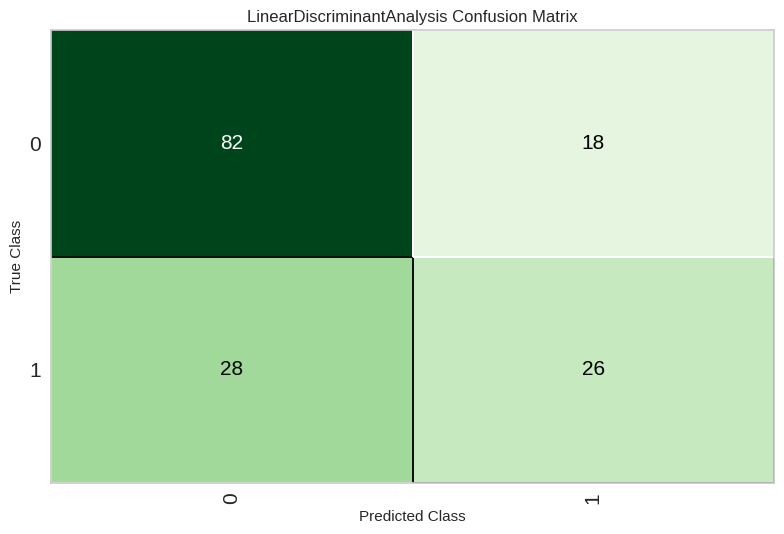

In [10]:
plot_model(melhor, plot='confusion_matrix')

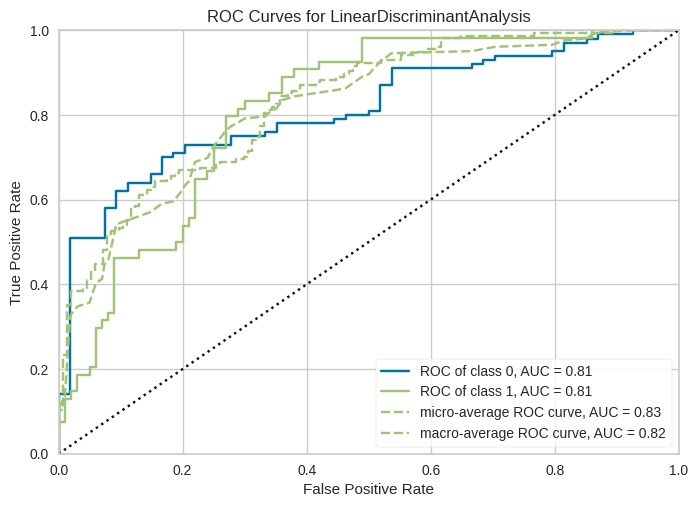

In [11]:
plot_model(melhor, plot='auc')

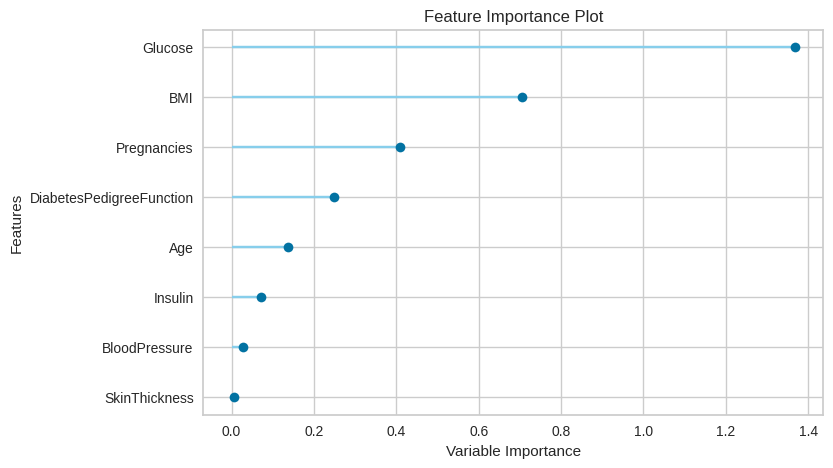

In [12]:
plot_model(melhor, plot='feature')

## 8. Comparação com o T2

No T2 foram treinados uma Regressão Logística e uma Árvore de Decisão (`max_depth=4`). Abaixo, a posição dos dois na tabela do PyCaret (quando presentes).

In [13]:
tabela_comparacao.loc[tabela_comparacao.index.isin(['lr', 'dt'])]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7818,0.8430,0.5844,0.7398,0.6497,0.4950,0.5044,0.026
dt,Decision Tree Classifier,0.6890,0.6635,0.5794,0.5519,0.5651,0.3233,0.3236,0.024


## 9. Conclusões

**O que foi feito:** Apliquei o PyCaret à mesma base do T2 (Pima Indians Diabetes, 768 pacientes, alvo Outcome), com o mesmo pré-processamento e a mesma divisão de 80% treino e 20% teste. Com compare_models(turbo=False), foram testados os 17 modelos de classificação da biblioteca.

**O melhor:** O melhor foi a Linear Discriminant Analysis (LDA), com acurácia média de 0,783 e AUC de 0,841 na validação cruzada. A Regressão Logística ficou praticamente empatada (0,782), e a diferença entre as duas é desprezível. Os modelos mais simples superaram os mais complexos (Random Forest, Gradient Boosting, LightGBM), o que sugere que os dados desta base se ajustam bem a fronteiras lineares. O Dummy, que sempre prevê "sem diabetes", teve 0,652, então os melhores modelos aprenderam algo, mas o ganho é modesto.

**Resultado:** No conjunto de teste, a LDA teve acurácia de 0,701, AUC de 0,813 e recall de 0,481. A queda em relação à validação cruzada é esperada, pois o teste é pequeno (cerca de 154 pacientes).

**Limitação:** A principal limitação é o recall: o modelo identificou menos da metade dos pacientes com diabetes. Em saúde, deixar de detectar um doente é grave, então a acurácia sozinha não basta, e o modelo serviria no máximo como triagem inicial.

Em resumo, o PyCaret confirmou o que o T2 indicava: a Regressão Logística é adequada para esta base. Nenhum modelo se destacou de forma clara, o que sugere que o limite está mais nos dados (poucas observações e variáveis) do que na escolha do algoritmo.